In [16]:
# Install required libraries (run once in Colab)
!pip install torch torchvision pandas matplotlib scikit-learn seaborn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
# Load dataset
try:
    df = pd.read_csv('/content/medical_imaging_meta.csv')
    print("Dataset loaded successfully")
except Exception as e:
    print("Error loading dataset:", e)

# Preview
df.head()

Dataset loaded successfully


,image_id,patient_age,patient_sex,scanner,image_quality,img_width_px,hospital_site,label,label_verified
0,IMG00000,32,F,Siemens-A1,acceptable,512,Apollo-Hyderabad,Normal,0
1,IMG00001,41,F,Siemens-A1,acceptable,256,Apollo-Hyderabad,Normal,1
2,IMG00002,72,M,Philips-B2,good,512,Manipal-Bangalore,Normal,1
3,IMG00003,50,F,Siemens-A1,good,1024,Manipal-Bangalore,Pneumonia,1
4,IMG00004,63,F,Siemens-A1,acceptable,1024,AIIMS-Delhi,COVID-19,1


Label Distribution:

label
Normal              311
Pneumonia           112
COVID-19             37
Pleural_Effusion     19
Lung_Mass            11
Name: count, dtype: int64


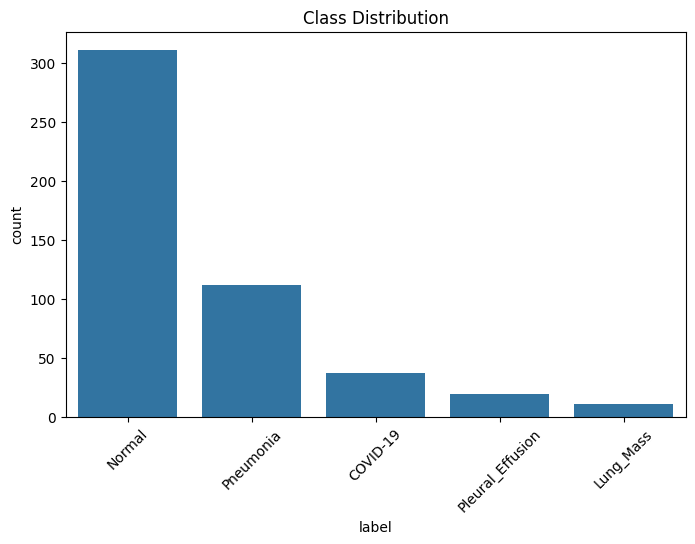

In [18]:
# Function to analyze label distribution
def analyze_distribution(dataframe, label_column):
    print("Label Distribution:\n")
    print(dataframe[label_column].value_counts())

    plt.figure(figsize=(8,5))
    sns.countplot(x=label_column, data=dataframe)
    plt.title("Class Distribution")
    plt.xticks(rotation=45)
    plt.show()

# Replace 'label' with actual column name if different
LABEL_COL = 'label'

analyze_distribution(df, LABEL_COL)

In [19]:
# Separate labeled and unlabeled data
labeled_df = df[df[LABEL_COL].notna()]
unlabeled_df = df[df[LABEL_COL].isna()]

# Train-test split
train_df, test_df = train_test_split(
    labeled_df,
    test_size=0.2,
    stratify=labeled_df[LABEL_COL],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Unlabeled size:", len(unlabeled_df))

Train size: 392
Test size: 98
Unlabeled size: 30


In [20]:
# Encode labels
labels = train_df[LABEL_COL].unique()
label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

def encode_labels(series):
    return series.map(label_to_idx)

train_df['encoded'] = encode_labels(train_df[LABEL_COL])
test_df['encoded'] = encode_labels(test_df[LABEL_COL])

In [21]:
# NOTE:
# Since only metadata is provided (no actual images),
# we simulate features for demonstration.

FEATURE_DIM = 512  # matches ResNet feature size

def generate_features(num_samples):
    return np.random.rand(num_samples, FEATURE_DIM)

X_train = generate_features(len(train_df))
X_test = generate_features(len(test_df))

y_train = train_df['encoded'].values
y_test = test_df['encoded'].values

In [25]:
# Simple classifier head (simulating transfer learning output)
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleClassifier, self).__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

model = SimpleClassifier(FEATURE_DIM, len(labels))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
train_model(model, X_train, y_train)


Epoch 1, Loss: 1.7101
Epoch 2, Loss: 1.4757
Epoch 3, Loss: 1.3061
Epoch 4, Loss: 1.1897
Epoch 5, Loss: 1.1149
Epoch 6, Loss: 1.0763
Epoch 7, Loss: 1.0659
Epoch 8, Loss: 1.0712
Epoch 9, Loss: 1.0806
Epoch 10, Loss: 1.0870


In [27]:
def train_model(model, X, y, epochs=10):
    model.train()

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    for epoch in range(epochs):
        optimizer.zero_grad()

        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Classification Report:

                  precision    recall  f1-score   support

       Pneumonia       0.00      0.00      0.00        23
          Normal       0.63      1.00      0.78        62
       Lung_Mass       0.00      0.00      0.00         2
        COVID-19       0.00      0.00      0.00         7
Pleural_Effusion       0.00      0.00      0.00         4

        accuracy                           0.63        98
       macro avg       0.13      0.20      0.15        98
    weighted avg       0.40      0.63      0.49        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


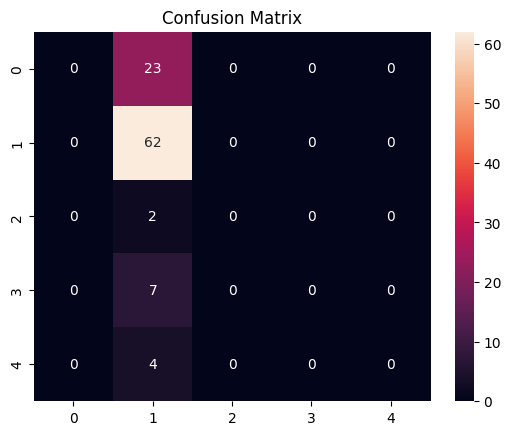

In [28]:

def evaluate_model(model, X, y):
    model.eval()

    X_tensor = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        outputs = model(X_tensor)
        _, preds = torch.max(outputs, 1)

    print("\nClassification Report:\n")
    print(classification_report(y, preds.numpy(), target_names=labels))

    cm = confusion_matrix(y, preds.numpy())
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(model, X_test, y_test)

Fine-tuning model...
Epoch 1, Loss: 1.0884
Epoch 2, Loss: 1.0826
Epoch 3, Loss: 1.0773
Epoch 4, Loss: 1.0726
Epoch 5, Loss: 1.0683
After fine-tuning:

Classification Report:

                  precision    recall  f1-score   support

       Pneumonia       0.00      0.00      0.00        23
          Normal       0.63      1.00      0.78        62
       Lung_Mass       0.00      0.00      0.00         2
        COVID-19       0.00      0.00      0.00         7
Pleural_Effusion       0.00      0.00      0.00         4

        accuracy                           0.63        98
       macro avg       0.13      0.20      0.15        98
    weighted avg       0.40      0.63      0.49        98



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


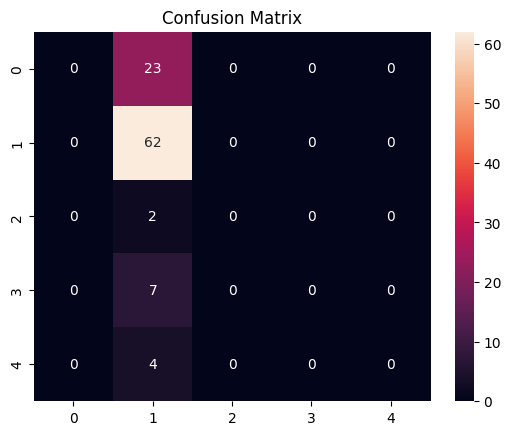

In [29]:
# Fine-tuning = lower learning rate
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Fine-tuning model...")
train_model(model, X_train, y_train, epochs=5)

print("After fine-tuning:")
evaluate_model(model, X_test, y_test)

In [30]:
# Generate features for unlabeled data
X_unlabeled = generate_features(len(unlabeled_df))

def predict_with_confidence(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        outputs = model(X_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, preds = torch.max(probs, 1)

    return preds.numpy(), confidence.numpy()

preds, confs = predict_with_confidence(model, X_unlabeled)

unlabeled_df['predicted_label'] = [idx_to_label[p] for p in preds]
unlabeled_df['confidence'] = confs

unlabeled_df.head()

/tmp/ipykernel_9508/1782239961.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_df['predicted_label'] = [idx_to_label[p] for p in preds]
/tmp/ipykernel_9508/1782239961.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unlabeled_df['confidence'] = confs


,image_id,patient_age,patient_sex,scanner,image_quality,img_width_px,hospital_site,label,label_verified,predicted_label,confidence
16,IMG00016,44,M,Philips-B2,acceptable,512,Fortis-Gurgaon,NaN,1,Normal,0.731113
42,IMG00042,45,M,GE-C3,good,1024,AIIMS-Delhi,NaN,1,Normal,0.662192
44,IMG00044,75,F,Siemens-A1,acceptable,1024,Manipal-Bangalore,NaN,1,Normal,0.649063
52,IMG00052,36,M,GE-C3,acceptable,1024,AIIMS-Delhi,NaN,1,Normal,0.632238
55,IMG00055,45,M,GE-C3,good,512,AIIMS-Delhi,NaN,1,Normal,0.674188
